In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from pydantic import SecretStr,BaseModel , Field 
from typing import TypedDict,NotRequired,Annotated, Literal
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
import operator
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver 
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from langgraph.prebuilt import ToolNode , tools_condition
from langchain_community.tools.ddg_search import DuckDuckGoSearchRun
from langchain_core.tools import tool
import requests
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore

from dotenv import load_dotenv

load_dotenv()

llm = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash",
    api_key = SecretStr(os.environ["GOOGLE_API_KEY"]),
)


C:\Users\welcome\AppData\Local\Temp\ipykernel_1896\4036950194.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.ddg_search import DuckDuckGoSearchRun


In [2]:
# ----------------------------
# 1) Create LTM store + seed memories (done BEFORE running the graph)
# ----------------------------
store = InMemoryStore()

user_id = "u1"

# Store user details as a single blob (simple for teaching)
# You can also split into multiple records; this keeps it easy.
user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Nitish"})
store.put(user_details, "profile_2", {"data": "Profession: Teaches AI on YouTube"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [3]:
# ----------------------------
# 2) System prompt template (your prompt)
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [4]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)

    # Convert memory items into a string blob for {user_details_content}
    # Keep it dead simple for teaching.
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)

    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

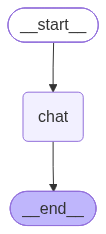

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [7]:
# ----------------------------
# 4) Run it (provide user_id in config)
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Explain gen ai in simple terms."}]},
    config,
)

print(result["messages"][-1].text)

Hey Nitish! Since you teach AI on YouTube, you know how powerful a simple analogy can be. Here is a quick, clear way to explain Generative AI to your audience:

### The Analogy: The Judge vs. The Creator
*   **Traditional AI (The Judge):** It looks at existing data and makes a decision. For example, "Is this email spam or not?" or "Is this a picture of a cat?"
*   **Generative AI (The Creator):** It learns from patterns in existing data to create something entirely new. Instead of just identifying a cat, it draws a brand-new cat from scratch. 

In short: **Traditional AI analyzes; Generative AI creates.**

---

### Gen AI in Action (Python Example)

Since you love Python, here is how we use Generative AI in code. We give it a prompt (the pattern), and it generates a unique response:

```python
import os
from openai import OpenAI

# Initialize the client (perfect for integrating into your MCP servers!)
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

response = client.chat.com